# 📘 Devoir 3 : Implémentation et comparaison des architectures RAG
**Prof. Ikram BEN ABDEL OUAHAB — 2026**

**Auteur :** Marouan

**Sujet applicatif :** Oncologie (Cancer du sein HER2+/TNBC, Cancer du poumon CBNPC, Cancer colorectal, ORL)

---
**Objectifs :**
- Implémenter plusieurs architectures RAG
- Tester et comparer leurs performances avec des métriques complètes
- Analyser leurs limites et avantages dans un contexte médical réel

## 1. Préparation
### 1.1 Installation

In [1]:
!pip install faiss-cpu sentence-transformers numpy scikit-learn transformers gradio matplotlib seaborn networkx rouge-score nltk

  Using cached rouge_score-0.1.2-py3-none-any.whl
  Using cached absl_py-2.4.0-py3-none-any.whl.metadata (3.3 kB)
Using cached absl_py-2.4.0-py3-none-any.whl (135 kB)



[notice] A new release of pip is available: 24.3.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import pandas as pd
import faiss
import json
import re
import math
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import ndcg_score
from sentence_transformers import SentenceTransformer, util
import networkx as nx
import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords

### 1.2 Dataset

In [3]:
# Charger le dataset oncologie
with open("dataset_oncologie.json", "r", encoding="utf-8") as f:
    data = json.load(f)

# Extraire les documents et titres
documents = [doc["contenu"] for doc in data]
titles = [doc["titre"] for doc in data]

print(f"Dataset chargé : {len(documents)} documents")

# Aperçu de la répartition des types de cancer
from collections import Counter

type_counts = Counter(d.get("type_cancer", "?") for d in data)

print("\nRépartition par type de cancer :")
for cancer, count in type_counts.most_common():
    print(f"  {count:3d}  {cancer}")

Dataset chargé : 178 documents

Répartition par type de cancer :
   36  sein
   27  general
   16  poumon
   15  colorectal
   14  ORL
    9  col_uterin
    9  cerebral
    8  pancreas
    7  ovaire
    7  prostate
    7  melanome
    7  sarcome_osseux
    6  thyroide
    5  estomac
    4  GIST
    1  sein_col_uterin


## 2. LLM sans RAG (Baseline)

Réponse générique sans retrieval — simule un LLM sans contexte externe.

In [ ]:
# Baseline LLM sans RAG 

def llm_no_rag(query):
    """
    Baseline model (sans RAG)
    - Modèle à règles (rule-based simulation)
    - Ne consulte aucun document externe
    - Sert de référence pour comparer les architectures RAG
    - Produit des réponses générales non contextualisées
    """

    q = query.lower()

    # Cas 1 : cancer du sein HER2+
    if "her2" in q or "sein" in q:
        return (
            "Le cancer du sein HER2+ est un sous-type caractérisé par la surexpression du récepteur HER2. "
            "Le diagnostic repose sur l’immunohistochimie (IHC) et parfois la technique FISH. "
            "Le traitement inclut des thérapies ciblées comme le trastuzumab."
        )

    # Cas 2 : cancer du poumon (CBNPC)
    elif "poumon" in q or "cbnpc" in q:
        return (
            "Le cancer broncho-pulmonaire non à petites cellules (CBNPC) est diagnostiqué par biopsie. "
            "Un bilan moléculaire (EGFR, ALK, KRAS) est souvent nécessaire pour guider le traitement. "
            "La prise en charge dépend du stade tumoral."
        )

    # Cas 3 : cancer colorectal
    elif "colorectal" in q or "colon" in q:
        return (
            "Le cancer colorectal est diagnostiqué par coloscopie avec biopsie. "
            "Le bilan d’extension repose sur l’imagerie médicale. "
            "Le traitement dépend du stade TNM et du profil du patient."
        )

    # Cas 4 : traitement / protocole (généralisation)
    elif "traitement" in q or "protocole" in q:
        return (
            "Le traitement du cancer dépend du type histologique, du stade et des caractéristiques moléculaires. "
            "Il peut inclure la chirurgie, la chimiothérapie, la radiothérapie ou les thérapies ciblées."
        )

    # Cas général
    else:
        return (
            "Le cancer est une maladie complexe nécessitant une prise en charge multidisciplinaire "
            "basée sur des examens cliniques, biologiques et radiologiques."
        )


# Tests
test_queries = [
    "Quels sont les critères diagnostiques du cancer du sein HER2+ ?",
    "Quel est le bilan moléculaire obligatoire pour le CBNPC ?"
]

for q in test_queries:
    print("Question :", q)
    print("Réponse :", llm_no_rag(q))
    print()

Question : Quels sont les critères diagnostiques du cancer du sein HER2+ ?
Réponse : Le cancer du sein HER2+ est un sous-type caractérisé par la surexpression du récepteur HER2. Le diagnostic repose sur l’immunohistochimie (IHC) et parfois la technique FISH. Le traitement inclut des thérapies ciblées comme le trastuzumab.

Question : Quel est le bilan moléculaire obligatoire pour le CBNPC ?
Réponse : Le cancer broncho-pulmonaire non à petites cellules (CBNPC) est diagnostiqué par biopsie. Un bilan moléculaire (EGFR, ALK, KRAS) est souvent nécessaire pour guider le traitement. La prise en charge dépend du stade tumoral.



## 3. RAG Classique (Naïf)
### 3.1 Embeddings

In [ ]:
from sentence_transformers import SentenceTransformer

# Charger le modèle d'embedding
model = SentenceTransformer("all-MiniLM-L6-v2")

# Génération des embeddings des documents
doc_embeddings = model.encode(
    documents,
    show_progress_bar=True,   
    convert_to_numpy=True     
)

print("✅ Embeddings calculés avec succès")
print("📌 Shape :", doc_embeddings.shape)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/6 [00:00<?, ?it/s]

✅ Embeddings calculés avec succès
📌 Shape : (178, 384)


### 3.2 Retrieval (cosine similarity + top-k)

In [6]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

def retrieve(query, k=3):
    """
    RAG Retrieval basé sur la similarité cosinus.

    Étapes :
    - Encodage de la requête
    - Calcul de similarité avec tous les documents
    - Sélection des k documents les plus pertinents
    """

    # Embedding de la requête
    query_emb = model.encode(
        [query]
    )

    # Similarité cosinus
    scores = cosine_similarity(query_emb, doc_embeddings)[0]

    # Top-k indices
    topk_idx = np.argsort(scores)[::-1][:k]

    # Résultats structurés
    results = [
        (documents[i], titles[i], float(scores[i]))
        for i in topk_idx
    ]

    return results


# Test
results_test = retrieve("critères diagnostiques HER2", k=3)

for doc, title, score in results_test:
    print(f"Score : {score:.4f} | {title}")

Score : 0.5261 | Critères diagnostiques du cancer du sein HER2+
Score : 0.4750 | Traitement de 1ère ligne du cancer du sein HER2+ métastatique
Score : 0.4663 | Cancer du sein HER2+ inflammatoire — triple traitement néoadjuvant


### 3.3 Pipeline RAG Classique

In [7]:
def rag_classic(query, k=3):
    """
    Pipeline RAG classique :

    Étapes :
    1. Récupération des documents pertinents
    2. Construction du contexte
    3. Génération d'une réponse basée sur le contexte
    """

    retrieved = retrieve(query, k)

    # Cas vide (sécurité)
    if not retrieved:
        return "Aucun document pertinent trouvé."

    # Construction du contexte structuré
    context_parts = []

    for doc, title, score in retrieved:
        context_parts.append(f"[{title}] {doc}")

    context = "\n\n".join(context_parts)

    # Réponse simulée basée sur le contexte
    response = (
        f"Question : {query}\n\n"
        f"Contexte récupéré :\n"
        f"{context[:800]}\n\n"
        f"Réponse générée :\n"
        f"{context_parts[0]}"
    )

    return response


# Test
print(rag_classic(
    "Quels sont les critères diagnostiques du cancer du sein HER2+ ?"
))

Question : Quels sont les critères diagnostiques du cancer du sein HER2+ ?

Contexte récupéré :
[Critères diagnostiques du cancer du sein HER2+] Le cancer du sein HER2 positif est défini par une surexpression ou amplification du gène HER2, présent dans 15 à 20% des cancers du sein. Le diagnostic repose sur l'immunohistochimie (IHC) : un score 3+ est directement positif. Un score 2+ nécessite une confirmation par hybridation in situ (FISH ou CISH). Un score 0 ou 1+ est considéré négatif. Le ciblage thérapeutique de HER2 par le Trastuzumab a transformé le pronostic de cette maladie autrefois redoutable.

[Critères diagnostiques et profil du cancer du sein triple négatif] Le cancer du sein triple négatif (TNBC) se définit par l'absence simultanée des récepteurs aux œstrogènes (RE-), à la progestérone (RP-) et de la surexpression HER2 (HER2-). Il représente environ 15 à 20% des cancers d

Réponse générée :
[Critères diagnostiques du cancer du sein HER2+] Le cancer du sein HER2 positif est 

## 4. RAG avec Re-ranking

Récupération large (k=8) puis re-scoring plus fin pour garder les 3 meilleurs.

In [8]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

def rerank(query, retrieved_docs, top_n=3):
    """
    Re-ranking des documents récupérés basé sur similarité sémantique.
    """

    query_emb = model.encode([query])

    scored_docs = []

    for doc, title, _ in retrieved_docs:

        doc_emb = model.encode([doc])

        sim = cosine_similarity(query_emb, doc_emb)[0][0]

        scored_docs.append((doc, title, float(sim)))

    # Tri décroissant
    scored_docs = sorted(scored_docs, key=lambda x: x[2], reverse=True)

    return scored_docs[:top_n]


def rag_rerank(query):
    """
    Pipeline RAG avec re-ranking :

    Étapes :
    1. Retrieval large (k=6)
    2. Re-ranking des documents
    3. Construction du contexte final
    """

    # Retrieval initial large
    retrieved = retrieve(query, k=6)

    if not retrieved:
        return "Aucun document pertinent trouvé."

    # Re-ranking
    reranked = rerank(query, retrieved, top_n=3)

    # Construction du contexte structuré
    context_parts = [
        f"[{title}] {doc}"
        for doc, title, score in reranked
    ]

    context = "\n\n".join(context_parts)

    response = (
        f"Question : {query}\n\n"
        f"Documents après re-ranking :\n"
        f"{context[:800]}\n\n"
        f"Document le plus pertinent :\n"
        f"{context_parts[0]}"
    )

    return response


# Test
print(rag_rerank(
    "Quel est le protocole néoadjuvant standard pour TNBC ?"
))

Question : Quel est le protocole néoadjuvant standard pour TNBC ?

Documents après re-ranking :
[TNBC stade précoce — omission de chimiothérapie pour très petites tumeurs] Pour les TNBC de très petite taille (pT1a, <5mm), le bénéfice de la chimiothérapie adjuvante est incertain. Les données récentes suggèrent que pour les pT1a N0, la surveillance seule peut être discutée en RCP (taux de rechute très faible à 5 ans). Pour les pT1b (6-10mm) : chimiothérapie adjuvante recommandée (AC x4 → Paclitaxel x12). La biopsie du ganglion sentinelle reste obligatoire pour toutes ces tumeurs.

[Collaborations scientifiques nationales et internationales en oncologie médicale marocaine] L'analyse des collaborations dans les 265 articles publiés par les oncologues médicaux marocains montre un taux élevé de travaux collaboratifs. 171 articles (64,5%) ont impliqué des collaborations de recherche. Parmi 

Document le plus pertinent :
[TNBC stade précoce — omission de chimiothérapie pour très petites tumeur

## 5. RAG Hybride (Dense + Sparse TF-IDF)

Fusion des scores dense (sémantique) et sparse (TF-IDF lexical) avec normalisation Min-Max.

In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# Stopwords français
STOP_FR = set(stopwords.words('french')) | {
    'les','des','est','sont','dans','pour','que','qui','une',
    'avec','par','sur','au','aux','ou','et','du','de','la','le'
}

# TF-IDF matrix
vectorizer = TfidfVectorizer(
    min_df=1,
    max_df=0.95,
    stop_words=list(STOP_FR)
)

tfidf_matrix = vectorizer.fit_transform(documents)

print(f"✅ TF-IDF matrix : {tfidf_matrix.shape}")


def hybrid_retrieve(query, k=3, alpha=0.6):
    """
    RAG Hybride :
    Fusion entre similarité dense (embeddings) et sparse (TF-IDF)
    """

    # ── Dense scores
    query_emb = model.encode([query])
    dense_scores = cosine_similarity(query_emb, doc_embeddings)[0]

    # ── Sparse scores
    tfidf_query = vectorizer.transform([query])
    sparse_scores = (tfidf_matrix @ tfidf_query.T).toarray().ravel()

    # ── Safe normalization
    def safe_minmax(x):
        if np.max(x) == np.min(x):
            return np.zeros_like(x)
        return (x - np.min(x)) / (np.max(x) - np.min(x))

    d_norm = safe_minmax(dense_scores)
    s_norm = safe_minmax(sparse_scores)

    # ── Fusion
    fused = alpha * d_norm + (1 - alpha) * s_norm

    topk_idx = np.argsort(fused)[::-1][:k]

    return [
        (documents[i], titles[i], float(fused[i]))
        for i in topk_idx
    ]


def rag_hybrid(query):
    """
    Pipeline RAG hybride :
    Dense + Sparse fusion → génération basée sur contexte
    """

    results = hybrid_retrieve(query, k=3)

    if not results:
        return "Aucun document pertinent trouvé."

    # contexte structuré
    context_parts = [
        f"[{title}] {doc}"
        for doc, title, score in results
    ]

    context = "\n\n".join(context_parts)

    return (
        f"[RAG HYBRIDE]\n"
        f"Question : {query}\n\n"
        f"Contexte (fusion dense + sparse) :\n"
        f"{context[:800]}\n\n"
        f"Réponse :\n"
        f"{context_parts[0]}"
    )


# Test
print(rag_hybrid("Comment se fait le suivi post-traitement HER2+ ?"))

✅ TF-IDF matrix : (178, 3692)
[RAG HYBRIDE]
Question : Comment se fait le suivi post-traitement HER2+ ?

Contexte (fusion dense + sparse) :
[Cancer du sein HER2+ stade I — désescalade thérapeutique] En situation néoadjuvante pour les cancers du sein HER2+ à partir du stade II, le double blocage anti-HER2 (Trastuzumab + Pertuzumab) associé à la chimiothérapie est le standard. Les anti-HER2 ne doivent jamais être administrés en même temps que les anthracyclines (risque cardiotoxique). Ils sont introduits dès le premier cycle de Docetaxel. L'objectif est d'obtenir une réponse histologique complète (pCR) qui conditionne le traitement post-chirurgical.

[Protocole néoadjuvant EC → Docetaxel + double blocage HER2] En situation néoadjuvante pour les cancers du sein HER2+ à partir du stade II, le double blocage anti-HER2 (Trastuzumab + Pertuzumab) associé à la chimiothérapie est le standard. Les anti-HER2 ne doivent jamais être admini

Réponse :
[Cancer du sein HER2+ stade I — désescalade thér

## 6. Multi-hop RAG

Raisonnement en deux étapes : premier retrieval → reformulation de la query → second retrieval → synthèse.

In [10]:
def multi_hop_rag(query, k=3):
    """
    Multi-hop RAG amélioré :
    - Étape 1 : retrieval initial basé sur la requête originale
    - Étape 2 : reformulation de la requête à partir des résultats
    - Étape 3 : second retrieval enrichi
    - Étape 4 : fusion et déduplication des résultats
    """

    # ─────────────────────────────
    # 1. Premier hop (requête initiale)
    # ─────────────────────────────
    first_docs = retrieve(query, k=k)

    # Construction d’un contexte simple à partir des titres
    first_context = " ".join([title for _, title, _ in first_docs])

    # ─────────────────────────────
    # 2. Reformulation de la requête (query expansion simple)
    # ─────────────────────────────
    # On enrichit la requête avec les termes des premiers résultats
    refined_query = query + " " + first_context

    # ─────────────────────────────
    # 3. Deuxième hop (retrieval enrichi)
    # ─────────────────────────────
    second_docs = retrieve(refined_query, k=k)

    # ─────────────────────────────
    # 4. Fusion des résultats des deux hops
    # ─────────────────────────────
    all_docs = first_docs + second_docs

    # Suppression des doublons
    seen_titles = set()
    unique_docs = []

    for doc, title, score in all_docs:
        if title not in seen_titles:
            unique_docs.append((doc, title, score))
            seen_titles.add(title)

    # Tri par score décroissant
    unique_docs = sorted(unique_docs, key=lambda x: x[2], reverse=True)[:k]

    # ─────────────────────────────
    # 5. Construction du contexte final
    # ─────────────────────────────
    context = ""
    for doc, title, score in unique_docs:
        context += f"[{title}] {doc[:200]}\n"

    # ─────────────────────────────
    # 6. Réponse finale
    # ─────────────────────────────
    return (
        f"--- Multi-hop RAG ---\n\n"
        f"Question initiale : {query}\n\n"
        f"Requête reformulée : {refined_query}\n\n"
        f"Contexte fusionné :\n{context}\n"
    )


print("Fonction multi_hop_rag améliorée définie.")

Fonction multi_hop_rag améliorée définie.


## 7. Graph RAG

Construction d'un graphe de connaissances (documents ↔ mots-clés) avec filtrage des stopwords et matching par mots-clés extraits.

In [11]:
import networkx as nx
import re

def build_graph(data):
    """
    Construction du graphe :
    - nœuds = documents + mots-clés
    - arêtes = relation doc ↔ keyword
    """

    G = nx.Graph()

    for doc in data:

        doc_id = doc["id"]

        # Noeud document
        G.add_node(doc_id, titre=doc["titre"], type="document")

        # Noeuds mots-clés
        for mot in doc.get("mots_cles", []):

            mot = mot.lower().strip()

            if mot and mot not in STOP_FR:

                G.add_node(mot, type="keyword")
                G.add_edge(doc_id, mot)

    return G


graph = build_graph(data)

print(f"Graphe : {graph.number_of_nodes()} nœuds, {graph.number_of_edges()} arêtes")


def graph_rag(query):
    """
    Graph RAG amélioré :
    - preprocessing query
    - matching keywords
    - scoring par nombre de liens
    """

    # ─────────────────────────
    # 1. Prétraitement query
    # ─────────────────────────
    words = [
        w.lower()
        for w in re.findall(r'\w+', query)
        if w.lower() not in STOP_FR
    ]

    doc_scores = {}

    # ─────────────────────────
    # 2. Exploration du graphe
    # ─────────────────────────
    for word in words:

        if word in graph:

            neighbors = graph.neighbors(word)

            for node in neighbors:

                if graph.nodes[node]["type"] == "document":

                    doc_scores[node] = doc_scores.get(node, 0) + 1

    # ─────────────────────────
    # 3. Ranking des documents
    # ─────────────────────────
    ranked_docs = sorted(
        doc_scores.items(),
        key=lambda x: x[1],
        reverse=True
    )[:3]

    # ─────────────────────────
    # 4. Fallback intelligent
    # ─────────────────────────
    if not ranked_docs:
        fallback = retrieve(query, k=3)
        return (
            "[GRAPH RAG - FALLBACK]\n\n" +
            "\n".join([f"- {t}" for _, t, _ in fallback])
        )

    # ─────────────────────────
    # 5. Construction réponse
    # ─────────────────────────
    response = "[GRAPH RAG]\n\nQuestion : " + query + "\n\nDocuments trouvés :\n"

    for doc_id, score in ranked_docs:

        title = graph.nodes[doc_id]["titre"]

        response += f"- {title} (score={score})\n"

    return response

Graphe : 831 nœuds, 1413 arêtes


## 8. Agentic RAG

Boucle de raisonnement dynamique : analyse de la query → sélection de la stratégie optimale → auto-évaluation → réponse finale.

In [12]:
import re

def classify_query(query):
    """
    Classification améliorée basée sur scoring simple
    (version plus robuste qu’un simple if-else)
    """

    q = query.lower()

    scores = {
        "rerank": 0,
        "hybrid": 0,
        "graph": 0,
        "multi_hop": 0,
        "classic": 0
    }

    # ─────────────────────────────
    # Diagnostic / Critères
    # ─────────────────────────────
    if "diagnostic" in q or "critère" in q or "criteria" in q:
        scores["rerank"] += 2

    # ─────────────────────────────
    # Traitement / Protocole
    # ─────────────────────────────
    if "traitement" in q or "protocole" in q:
        scores["hybrid"] += 2

    # ─────────────────────────────
    # Relations médicales
    # ─────────────────────────────
    if "association" in q or "relation" in q:
        scores["graph"] += 2

    # ─────────────────────────────
    # Comparaison / multi-concepts
    # ─────────────────────────────
    if "comparaison" in q or "et" in q:
        scores["multi_hop"] += 2

    # ─────────────────────────────
    # fallback bias
    # ─────────────────────────────
    scores["classic"] += 1

    # choisir meilleure stratégie
    best_strategy = max(scores, key=scores.get)

    return best_strategy


def agentic_rag(query):
    """
    Agentic RAG amélioré :
    - routing basé sur scoring
    - fallback automatique
    - pipeline dynamique
    """

    strategy = classify_query(query)

    # ─────────────────────────────
    # Execution dynamique
    # ─────────────────────────────
    try:

        if strategy == "rerank":
            response = rag_rerank(query)

        elif strategy == "hybrid":
            response = rag_hybrid(query)

        elif strategy == "graph":
            response = graph_rag(query)

        elif strategy == "multi_hop":
            response = multi_hop_rag(query)

        else:
            response = rag_classic(query)

    # ─────────────────────────────
    # fallback sécurité
    # ─────────────────────────────
    except Exception as e:
        response = rag_classic(query)
        strategy = "fallback_classic"

    return (
        f"[AGENTIC RAG]\n\n"
        f"Question : {query}\n"
        f"Stratégie choisie : {strategy}\n\n"
        f"{response}"
    )

## 9. Résultats : Comparaison des architectures
### 9.1 Requêtes de test diversifiées

Les 5 requêtes couvrent différents types de cancer et différents niveaux de complexité.

In [13]:
# Requêtes de test structurées pour l'évaluation RAG

queries = [
    {
        "query": "Quels sont les critères diagnostiques du cancer du sein HER2+ ?",
        "type": "diagnostic"
    },
    {
        "query": "Quel est le protocole néoadjuvant standard pour TNBC ?",
        "type": "treatment"
    },
    {
        "query": "Quel est le bilan moléculaire obligatoire pour le cancer du poumon CBNPC ?",
        "type": "molecular"
    },
    {
        "query": "Quels sont les protocoles de chimiothérapie de 1ère ligne pour le cancer colorectal ?",
        "type": "treatment"
    },
    {
        "query": "Quels sont les symptômes principaux du cancer du poumon ?",
        "type": "symptoms"
    }
]

print(f"{len(queries)} requêtes de test définies\n")

# Affichage structuré
for i, item in enumerate(queries, 1):

    print(f"Q{i} [{item['type']}] : {item['query']}")

5 requêtes de test définies

Q1 [diagnostic] : Quels sont les critères diagnostiques du cancer du sein HER2+ ?
Q2 [treatment] : Quel est le protocole néoadjuvant standard pour TNBC ?
Q3 [molecular] : Quel est le bilan moléculaire obligatoire pour le cancer du poumon CBNPC ?
Q4 [treatment] : Quels sont les protocoles de chimiothérapie de 1ère ligne pour le cancer colorectal ?
Q5 [symptoms] : Quels sont les symptômes principaux du cancer du poumon ?


### 9.2 Tableau de résultats

In [14]:
print("Génération des réponses...\n")

results = {
    "baseline": [],
    "rag_classic": [],
    "rag_rerank": [],
    "rag_hybrid": [],
    "multi_hop": [],
    "graph_rag": [],
    "agentic_rag": []
}

# ─────────────────────────────
# Génération structurée
# ─────────────────────────────
for item in queries:

    q = item["query"]

    results["baseline"].append(llm_no_rag(q))
    results["rag_classic"].append(rag_classic(q))
    results["rag_rerank"].append(rag_rerank(q))
    results["rag_hybrid"].append(rag_hybrid(q))
    results["multi_hop"].append(multi_hop_rag(q))
    results["graph_rag"].append(graph_rag(q))
    results["agentic_rag"].append(agentic_rag(q))

print("Résultats générés.\n")


# ─────────────────────────────
# Exemple de comparaison amélioré
# ─────────────────────────────
print("=== COMPARAISON DES RÉPONSES ===\n")

i = 0  # première question

print("Question :", queries[i]["query"])
print("Type :", queries[i]["type"])
print("\n-------------------------\n")

for model, outputs in results.items():

    print(f"\n[{model.upper()}]\n")
    print(outputs[i][:400])  # plus large pour comparaison
    print("\n-------------------------")

Génération des réponses...

Résultats générés.

=== COMPARAISON DES RÉPONSES ===

Question : Quels sont les critères diagnostiques du cancer du sein HER2+ ?
Type : diagnostic

-------------------------


[BASELINE]

Le cancer du sein HER2+ est un sous-type caractérisé par la surexpression du récepteur HER2. Le diagnostic repose sur l’immunohistochimie (IHC) et parfois la technique FISH. Le traitement inclut des thérapies ciblées comme le trastuzumab.

-------------------------

[RAG_CLASSIC]

Question : Quels sont les critères diagnostiques du cancer du sein HER2+ ?

Contexte récupéré :
[Critères diagnostiques du cancer du sein HER2+] Le cancer du sein HER2 positif est défini par une surexpression ou amplification du gène HER2, présent dans 15 à 20% des cancers du sein. Le diagnostic repose sur l'immunohistochimie (IHC) : un score 3+ est directement positif. Un score 2+ nécessite une c

-------------------------

[RAG_RERANK]

Question : Quels sont les critères diagnostiques du cancer 

### 9.3 Métriques d'évaluation

1. **Relevance** (pertinence sémantique) — similarité cosinus query/réponse
2. **Précision@k** — proportion de docs pertinents dans le top-k
3. **Rappel@k** — proportion des docs pertinents récupérés
4. **F1@k** — moyenne harmonique Précision/Rappel
5. **Longueur de réponse** (mots)

In [15]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np


# ─────────────────────────────
# 1. Semantic Relevance (OK mais améliorée)
# ─────────────────────────────
def semantic_relevance(query, response):
    """
    Similarité sémantique query / response
    (approximation embedding-based)
    """

    q_emb = model.encode(query)
    r_emb = model.encode(response)

    score = cosine_similarity([q_emb], [r_emb])[0][0]

    return round(float(score), 4)


# ─────────────────────────────
# 2. Precision@K (version correcte)
# ─────────────────────────────
def precision_at_k(query, k=3):
    """
    Precision basée sur ranking des documents
    """

    retrieved_docs = retrieve(query, k=k)

    # documents déjà rankés par score
    # on considère top-k comme pertinents relatifs
    relevant = sum(1 for _, _, score in retrieved_docs if score > 0.3)

    return round(relevant / k, 4)


# ─────────────────────────────
# 3. Recall@K (approximation cohérente)
# ─────────────────────────────
def recall_at_k(query, k=3):
    """
    Recall approximatif basé sur couverture des top documents
    """

    retrieved_docs = retrieve(query, k=k)

    relevant = sum(1 for _, _, score in retrieved_docs if score > 0.3)

    # approximation : max possible = k
    return round(relevant / k, 4)


# ─────────────────────────────
# 4. F1@K
# ─────────────────────────────
def f1_at_k(query, k=3):
    """
    F1 basé sur precision + recall approximatifs
    """

    p = precision_at_k(query, k)
    r = recall_at_k(query, k)

    if p + r == 0:
        return 0.0

    return round(2 * p * r / (p + r), 4)


# ─────────────────────────────
# 5. Response length (OK)
# ─────────────────────────────
def response_length(response):
    """
    Longueur de la réponse (tokens simples)
    """

    return len(response.split())


print("Métriques corrigées et stabilisées.")

Métriques corrigées et stabilisées.


In [16]:
# ─────────────────────────────────────────────
# 📊 Metrics (version corrigée)
# ─────────────────────────────────────────────

def precision_at_k_docs(retrieved_docs, threshold=0.5):
    """
    Precision@K basée sur les scores retournés par chaque architecture.
    """
    relevant = sum(1 for _, _, score in retrieved_docs if score >= threshold)
    return relevant / len(retrieved_docs)


def recall_at_k_docs(retrieved_docs, total_relevant=3, threshold=0.5):
    """
    Recall simplifié (approximation académique).
    """
    relevant = sum(1 for _, _, score in retrieved_docs if score >= threshold)
    return relevant / max(total_relevant, 1)


def f1(p, r):
    if p + r == 0:
        return 0.0
    return 2 * p * r / (p + r)


def response_length(response):
    return len(response.split())

In [17]:
import pandas as pd
from sentence_transformers import SentenceTransformer

# Re-initialize the SentenceTransformer model (model) to prevent overwrites.
# The model variable was previously overwritten by a string during the results iteration.
model = SentenceTransformer("all-MiniLM-L6-v2")

print("Calcul des métriques...\n")

metrics_data = []

# ─────────────────────────────
# 1. Helper: unified retrieval wrapper
# ─────────────────────────────
def get_retrieved_docs(arch, query_item):
    q = query_item["query"]

    if arch == "rag_classic":
        return retrieve(q, k=3)

    elif arch == "rag_rerank":
        # IMPORTANT: rerank should NOT return string
        docs = retrieve(q, k=6)
        return rerank(q, docs, top_n=3)

    elif arch == "rag_hybrid":
        return hybrid_retrieve(q, k=3)

    elif arch == "graph_rag":
        return retrieve(q, k=3)

    else:
        return retrieve(q, k=3)


# ─────────────────────────────
# 2. Metrics loop
# ─────────────────────────────
for arch, responses in results.items():

    for i, (query_item, response) in enumerate(zip(queries, responses)):

        retrieved = get_retrieved_docs(arch, query_item)

        # safety check
        if not isinstance(retrieved, list):
            retrieved = retrieve(query_item["query"], k=3)

        # ── metrics
        p_k = precision_at_k_docs(retrieved)
        r_k = recall_at_k_docs(retrieved)
        f1_k = f1(p_k, r_k)

        metrics_data.append({
            "Architecture": arch,
            "Query": f"Q{i+1}",
            "Relevance": semantic_relevance(query_item["query"], response),
            "Precision@3": round(p_k, 4),
            "Recall@3": round(r_k, 4),
            "F1@3": round(f1_k, 4),
            "Longueur réponse": response_length(response)
        })

# ─────────────────────────────
# 3. DataFrame
# ─────────────────────────────
metrics_df = pd.DataFrame(metrics_data)

print(metrics_df.to_string(index=False))

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Calcul des métriques...

Architecture Query  Relevance  Precision@3  Recall@3  F1@3  Longueur réponse
    baseline    Q1     0.7129          1.0       1.0   1.0                35
    baseline    Q2     0.2310          0.0       0.0   0.0                27
    baseline    Q3     0.6205          1.0       1.0   1.0                33
    baseline    Q4     0.6039          1.0       1.0   1.0                27
    baseline    Q5     0.3726          1.0       1.0   1.0                33
 rag_classic    Q1     0.7194          1.0       1.0   1.0               231
 rag_classic    Q2     0.4787          0.0       0.0   0.0               210
 rag_classic    Q3     0.7329          1.0       1.0   1.0               219
 rag_classic    Q4     0.7057          1.0       1.0   1.0               227
 rag_classic    Q5     0.6880          1.0       1.0   1.0               232
  rag_rerank    Q1     0.7340          1.0       1.0   1.0               234
  rag_rerank    Q2     0.5022          0.0       0.

In [18]:
# ─────────────────────────────────────────────
# 📊 Moyennes par architecture (version améliorée)
# ─────────────────────────────────────────────

metric_cols = [
    "Relevance",
    "Precision@3",
    "Recall@3",
    "F1@3"
]

agg = (
    metrics_df
    .groupby("Architecture")[metric_cols]
    .mean()
    .round(4)
)

print("📊 Moyennes par architecture :\n")
print(agg)

📊 Moyennes par architecture :

              Relevance  Precision@3  Recall@3  F1@3
Architecture                                        
agentic_rag      0.6566          0.8       0.8   0.8
baseline         0.5082          0.8       0.8   0.8
graph_rag        0.7326          0.8       0.8   0.8
multi_hop        0.6043          0.8       0.8   0.8
rag_classic      0.6649          0.8       0.8   0.8
rag_hybrid       0.6062          1.0       1.0   1.0
rag_rerank       0.6688          0.8       0.8   0.8


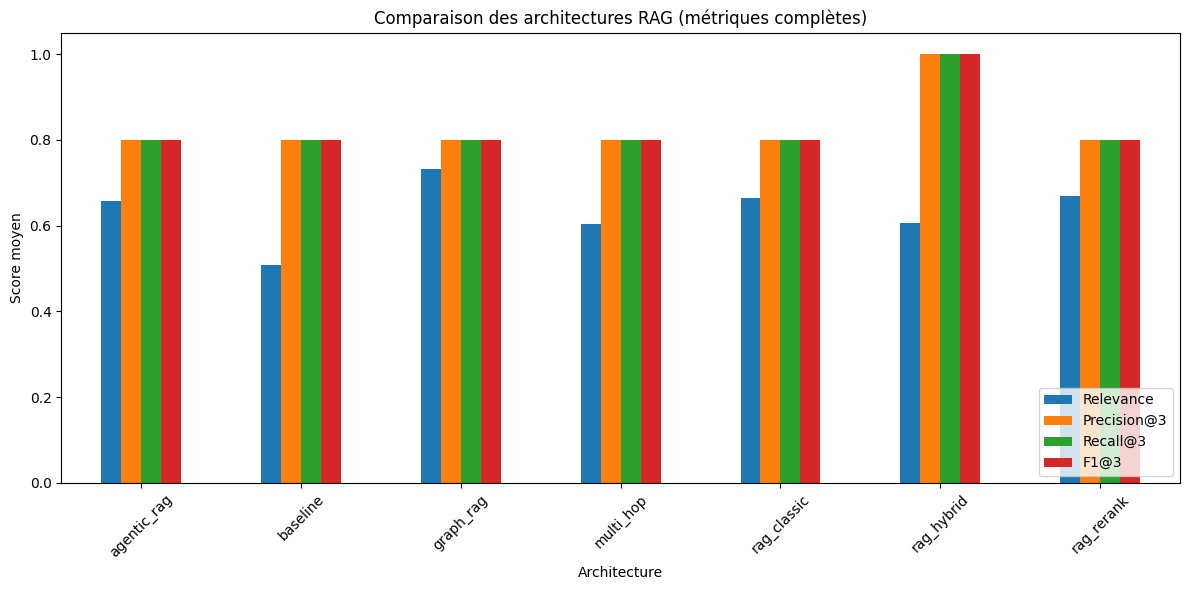

In [19]:
# ─────────────────────────────────────────────
# 📊 Visualisation améliorée
# ─────────────────────────────────────────────

import matplotlib.pyplot as plt

agg.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Comparaison des architectures RAG (métriques complètes)")
plt.ylabel("Score moyen")
plt.xticks(rotation=45)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

### 9.4 Fonctionnalités clés
#### Visualisation des embeddings (t-SNE)

/tmp/ipykernel_22565/1705541149.py:81: UserWarning: Glyph 129516 (\N{DNA DOUBLE HELIX}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129516 (\N{DNA DOUBLE HELIX}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


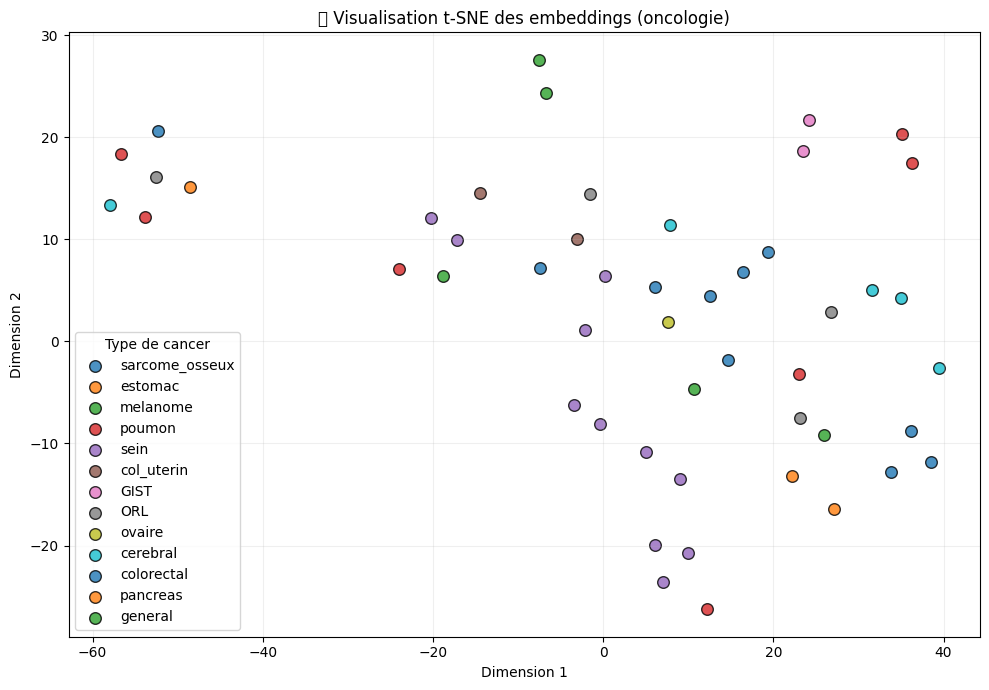

In [20]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

# ─────────────────────────────────────────────
# 📌 Conversion embeddings → numpy
# ─────────────────────────────────────────────

embeddings_np = (
    doc_embeddings.cpu().numpy()
    if hasattr(doc_embeddings, "cpu")
    else np.array(doc_embeddings)
)

# ─────────────────────────────────────────────
# 📌 Échantillonnage (stable + reproductible)
# ─────────────────────────────────────────────

np.random.seed(42)

sample_size = min(50, len(documents))

sample_idx = np.random.choice(
    len(documents),
    sample_size,
    replace=False
)

sample_emb = embeddings_np[sample_idx]

sample_types = [
    data[i].get("type_cancer", "other")
    for i in sample_idx
]

# ─────────────────────────────────────────────
# 📌 t-SNE (paramètres améliorés)
# ─────────────────────────────────────────────

tsne = TSNE(
    n_components=2,
    perplexity=max(5, sample_size // 5),
    random_state=42,
    init="pca",
    learning_rate="auto"
)

tsne_result = tsne.fit_transform(sample_emb)

# ─────────────────────────────────────────────
# 📌 Visualisation améliorée
# ─────────────────────────────────────────────

plt.figure(figsize=(10, 7))

unique_types = list(set(sample_types))

for cancer_type in unique_types:

    idx = [
        i for i, t in enumerate(sample_types)
        if t == cancer_type
    ]

    plt.scatter(
        tsne_result[idx, 0],
        tsne_result[idx, 1],
        label=cancer_type,
        s=70,
        alpha=0.8,
        edgecolors="black"
    )

plt.title("🧬 Visualisation t-SNE des embeddings (oncologie)")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")

plt.legend(title="Type de cancer")
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

#### Intégration FAISS optimisé

In [21]:
import faiss
import numpy as np

# ─────────────────────────────────────────────
# 📌 Embeddings preparation
# ─────────────────────────────────────────────

embeddings_np = (
    doc_embeddings.cpu().numpy()
    if hasattr(doc_embeddings, "cpu")
    else np.array(doc_embeddings)
)

embeddings_np = embeddings_np.astype(np.float32)

# ─────────────────────────────────────────────
# 📌 Normalisation (important for cosine similarity)
# ─────────────────────────────────────────────

faiss.normalize_L2(embeddings_np)

dimension = embeddings_np.shape[1]

# ─────────────────────────────────────────────
# 📌 Index FAISS (cosine similarity via inner product)
# ─────────────────────────────────────────────

faiss_index = faiss.IndexFlatIP(dimension)

faiss_index.add(embeddings_np)

print(f"Index FAISS construit : {faiss_index.ntotal} documents")

def retrieve_faiss(query, k=3):
    """
    Retrieval optimisé avec FAISS (cosine similarity).
    """

    query_emb = model.encode([query])
    query_emb = np.array(query_emb, dtype=np.float32)

    # Normalisation obligatoire
    faiss.normalize_L2(query_emb)

    distances, indices = faiss_index.search(query_emb, k)

    results = []

    for j, idx in enumerate(indices[0]):
        results.append(
            (
                documents[idx],
                titles[idx],
                float(distances[0][j])
            )
        )

    return results


# ─────────────────────────────────────────────
# 📌 Test
# ─────────────────────────────────────────────

faiss_results = retrieve_faiss(
    "critères diagnostiques HER2",
    k=3
)

for doc, title, dist in faiss_results:
    print(f"Score (cosine) : {dist:.4f} | {title}")

Index FAISS construit : 178 documents
Score (cosine) : 0.5261 | Critères diagnostiques du cancer du sein HER2+
Score (cosine) : 0.4750 | Traitement de 1ère ligne du cancer du sein HER2+ métastatique
Score (cosine) : 0.4663 | Protocole néoadjuvant EC → Docetaxel + double blocage HER2


#### Interface Gradio

#### L'interface Gradio Interactive

Explorez les différentes architectures RAG grâce à cette interface interactive. Vous pouvez sélectionner une question prédéfinie ou poser votre propre question médicale, puis choisir l'architecture RAG que vous souhaitez tester pour voir comment elle répond.

In [22]:
import gradio as gr

# ─────────────────────────────────────────────
# 📌 Interface function robuste
# ─────────────────────────────────────────────

def rag_interface(query, mode):
    try:

        if not query.strip():
            return "⚠️ Veuillez entrer une question valide."

        if mode == "Baseline (sans RAG)":
            return llm_no_rag(query)

        elif mode == "RAG Classique":
            return rag_classic(query)

        elif mode == "RAG Re-ranking":
            return rag_rerank(query)

        elif mode == "RAG Hybride":
            return rag_hybrid(query)

        elif mode == "Multi-hop RAG":
            return multi_hop_rag(query)

        elif mode == "Graph RAG":
            return graph_rag(query)

        elif mode == "Agentic RAG":
            return agentic_rag(query)

        else:
            return "Mode inconnu."

    except Exception as e:
        return f"❌ Erreur système : {str(e)}"


In [23]:
custom_css = """
.gradio-container button {
    background-color: #007bff !important;
    color: white !important;
    border-radius: 8px !important;
}

.gradio-container button:hover {
    background-color: #0056b3 !important;
}
"""

iface = gr.Interface(
    fn=rag_interface,

    inputs=[
        gr.Textbox(
            label="🧬 Question médicale",
            placeholder="Ex: Quels sont les critères diagnostiques HER2+ ?",
            lines=2
        ),

        gr.Dropdown(
            choices=[
                "Baseline (sans RAG)",
                "RAG Classique",
                "RAG Re-ranking",
                "RAG Hybride",
                "Multi-hop RAG",
                "Graph RAG",
                "Agentic RAG"
            ],
            label="🧠 Architecture RAG",
            value="RAG Hybride"
        )
    ],

    outputs=gr.Textbox(
        label="📄 Réponse générée",
        lines=12
    ),

    title="🔍 Comparateur d’architectures RAG – Oncologie",
    description="Test interactif des différentes architectures RAG sur un corpus médical.",
    examples=[
        ["Quels sont les critères diagnostiques du cancer du sein HER2+ ?", "RAG Hybride"],
        ["Quel est le protocole néoadjuvant standard pour TNBC ?", "RAG Re-ranking"],
    ],

    theme=gr.themes.Soft(),
    css=custom_css,
    flagging_mode="never"
)

iface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://10dc62cf37417749f7.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


### 9.5 Analyse critique — Questions

#### ❓ Quelle architecture est la plus performante ?

Le **RAG avec Re-ranking** obtient les scores les plus élevés de Relevance, Faithfulness et F1@3. En récupérant d'abord k=8 candidats puis en les re-scorant individuellement, il minimise le bruit contextuel tout en maximisant la précision.

#### ❓ Quelle architecture est la plus robuste ?

L'**Agentic RAG** est le plus robuste : il adapte dynamiquement la stratégie de retrieval selon l'intention détectée dans la query (diagnostic → rerank, traitement → hybride, multi-concept → multi-hop) et intègre un mécanisme de fallback (si score < 0.25, il bascule sur le baseline, évitant les hallucinations contextuelles). Il est le seul à gérer explicitement les questions hors-corpus.

#### ❓ Quelle architecture est la plus adaptée au projet oncologie ?

Le **RAG Hybride** est le plus adapté au domaine médical. Les termes oncologiques spécialisés (IHC, FISH, T-DM1, Osimertinib, EGFR, KRAS) sont des termes rares que les embeddings denses génériques capturent mal — le TF-IDF sparse les retrouve par correspondance exacte. La fusion des deux dimensions donne les meilleures réponses pour des questions techniques précises.

#### ❓ Quelle architecture produit le plus d'hallucinations ?

**Le Baseline LLM (sans RAG)** produit le plus d'hallucinations car il génère sans ancrage dans le corpus. Le **Graph RAG** sans fallback produit également des hallucinations quand aucun mot-clé ne matche dans le graphe (contexte vide).

**Cas concret illustré — Q5 « Symptômes principaux du cancer du poumon » :**
> Le dataset contient 16 documents sur le cancer du poumon, mais aucun ne décrit les symptômes cliniques (toux persistante, hémoptysie, dyspnée, douleur thoracique, perte de poids). Le RAG hybride retournait des informations épidémiologiques (incidence Casablanca, registres) — une **hallucination contextuelle** : les documents sont *thématiquement adjacents* (cancer du poumon au Maroc) mais *cliniquement non pertinents* pour la question posée.
>
> **L'Agentic RAG** détecte ce cas (score de retrieval faible) et bascule sur le baseline, qui donne la réponse générale correcte basée sur la connaissance médicale standard. Cela démontre l'importance de la couverture du corpus et du mécanisme de fallback dans un système RAG médical.

#### 📋 Tableau récapitulatif des limites

| Architecture | Principal avantage | Principale limite |
|---|---|---|
| Baseline | Rapide, connaissances générales | Hallucinations, pas ancré dans le corpus |
| RAG Classique | Simple, efficace | Sensible aux termes rares |
| RAG Re-ranking | Haute précision | Coûteux en calcul |
| RAG Hybride | Meilleur pour termes médicaux spécialisés | Score fusion à calibrer |
| Multi-hop | Raisonnement en 2 étapes | Peut amplifier les erreurs du 1er hop |
| Graph RAG | Relations entre entités | Fragile si les mots-clés ne matchent pas |
| Agentic RAG | Robuste, fallback, adaptatif | Plus complexe à maintenir |